# Data loading

In [1]:
import pandas as pd
import pickle
from pathlib import Path

# Get the Code directory (project root)
current_dir = Path.cwd()  # from_scratch directory
code_dir = current_dir.parent.parent.parent.parent  # Go up to Code directory
print(f"Code directory: {code_dir}")

# Define all data paths directly
PATHS = {
    # Training features
    'X_train_smote': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_smote.parquet',
    'X_train_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_tomek.parquet',
    'X_train_smote_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Normalized_Data_split' / 'X_train_smote_tomek.parquet',
    
    # Training targets
    'y_train_smote': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'smote' / 'y_smote.pkl',
    'y_train_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'tomek' / 'y_tomek.pkl',
    'y_train_smote_tomek': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'smote_tomek' / 'y_smote_tomek.pkl',
    
    # Validation and test features
    'X_val': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'val' / 'X_val.parquet',
    'X_test': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'test' / 'X_test.parquet',
    
    # Validation and test targets
    'y_val': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'val' / 'y_val.pkl',
    'y_test': code_dir / 'Merged_Data_Preprocessing' / 'Resampled_Data_split' / 'test' / 'y_test.pkl',
}

# Print all paths for verification
print("\nData paths:")
for key, path in PATHS.items():
    exists = "✓" if path.exists() else "✗"
    print(f"  {exists} {key}: {path}")

# Load all data
def load_all_data():
    """Load all data files"""
    data = {}
    
    print("\n" + "="*50)
    print("LOADING DATA")
    print("="*50)
    
    # Load parquet files
    parquet_keys = ['X_train_smote', 'X_train_tomek', 'X_train_smote_tomek', 'X_val', 'X_test']
    for key in parquet_keys:
        path = PATHS[key]
        if path.exists():
            try:
                data[key] = pd.read_parquet(path)
                print(f"✓ Loaded {key}: {data[key].shape}")
            except Exception as e:
                print(f"✗ Error loading {key}: {e}")
        else:
            print(f"✗ Skipping {key}: file not found at {path}")
    
    # Load pickle files
    pickle_keys = ['y_train_smote', 'y_train_tomek', 'y_train_smote_tomek', 'y_val', 'y_test']
    for key in pickle_keys:
        path = PATHS[key]
        if path.exists():
            try:
                with open(path, 'rb') as f:
                    data[key] = pickle.load(f)
                print(f"✓ Loaded {key}: {len(data[key])} samples")
            except Exception as e:
                print(f"✗ Error loading {key}: {e}")
        else:
            print(f"✗ Skipping {key}: file not found at {path}")
    
    return data

# Load the data
data = load_all_data()

if data:
    print(f"\n" + "="*50)
    print(f"Successfully loaded {len(data)} datasets")
    print("="*50)
    for key, value in data.items():
        if hasattr(value, 'shape'):
            print(f"  {key}: {value.shape}")
        else:
            print(f"  {key}: {len(value)} samples")
else:
    print("\nNo data was loaded")

Code directory: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code

Data paths:
  ✓ X_train_smote: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Normalized_Data_split\X_train_smote.parquet
  ✓ X_train_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Normalized_Data_split\X_train_tomek.parquet
  ✓ X_train_smote_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Normalized_Data_split\X_train_smote_tomek.parquet
  ✓ y_train_smote: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Resampled_Data_split\smote\y_smote.pkl
  ✓ y_train_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessing\Resampled_Data_split\tomek\y_tomek.pkl
  ✓ y_train_smote_tomek: c:\Users\moous\Documents\M2\Fire-Detection-Data-Mining-Project\Code\Merged_Data_Preprocessi

# Clarans from scratch


STARTING CLARANS CLUSTERING & VISUALIZATION PIPELINE

--- Processing dataset: X_train_smote ---
Data shape: (30570, 64)
Running CLARANS fit...
CLARANS initialized with maxneighbor=200
Starting CLARANS (k=3, numlocal=3)...
  Local run 1/3 found new best cost: 12021254.50 (checked 557 neighbors)
  Local run 2/3 finished. Cost not improved.
  Local run 3/3 found new best cost: 12012065.96 (checked 566 neighbors)
Assigning labels...
Done. Duration: 54.72 seconds.
Performing PCA for 2D visualization...

--- Processing dataset: X_train_tomek ---
Data shape: (15911, 64)
Running CLARANS fit...
CLARANS initialized with maxneighbor=200
Starting CLARANS (k=3, numlocal=3)...
  Local run 1/3 found new best cost: 5344503.21 (checked 554 neighbors)
  Local run 2/3 finished. Cost not improved.
  Local run 3/3 found new best cost: 5342093.57 (checked 973 neighbors)
Assigning labels...
Done. Duration: 48.57 seconds.
Performing PCA for 2D visualization...

--- Processing dataset: X_train_smote_tomek ---

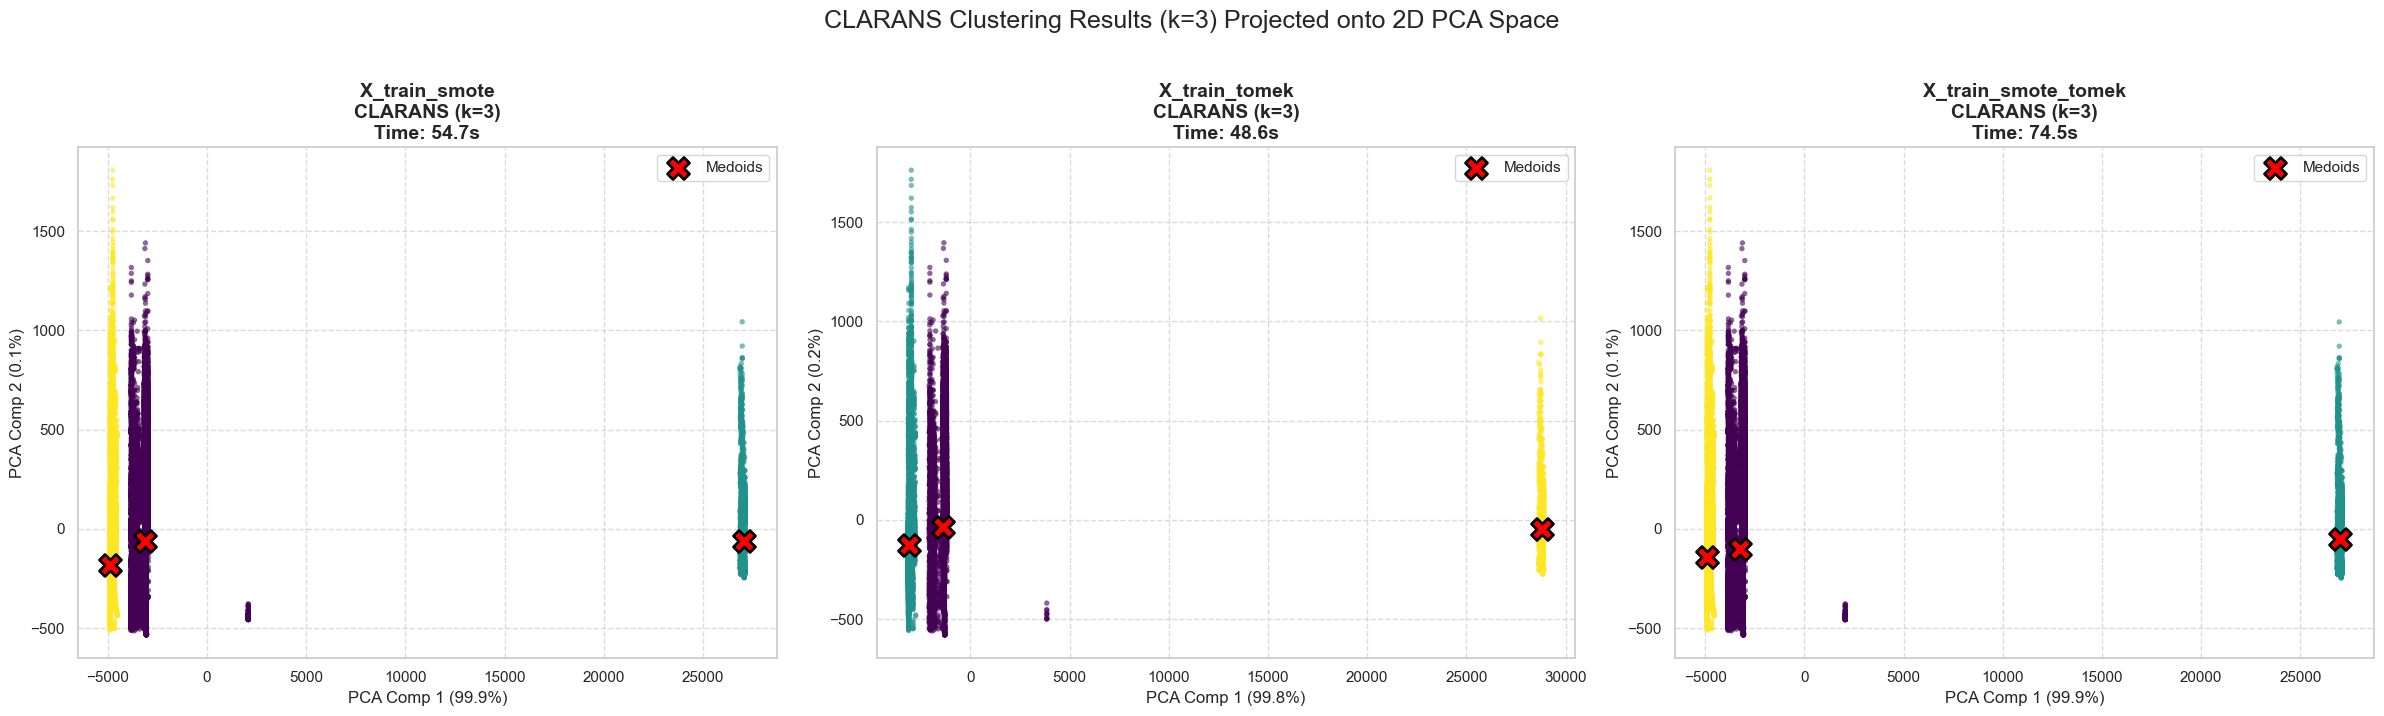


Cluster Distribution for SMOTE-Tomek:
0    20000
1     3661
2     6605
Name: count, dtype: int64


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
import random
import time
import sys

# Set plot style for better visuals
sns.set_theme(style="whitegrid")

# =========================================
# PART 1: CLARANS Implementation From Scratch
# =========================================

class CLARANS:
    """
    Clustering Large Applications based on RANdomized Search (CLARANS) implementation from scratch.
    """
    def __init__(self, k=3, numlocal=2, maxneighbor=None, random_state=42):
        self.k = k                  # Number of clusters
        self.numlocal = numlocal    # Number of local searches
        self.maxneighbor = maxneighbor # Max neighbors to explore per local search
        self.random_state = random_state
        self.medoids = None         # Indices of final medoids
        self.medoid_coords = None   # Coordinates of final medoids

    def _calculate_total_cost(self, X, medoid_indices):
        """
        Calculates the total cost: sum of distances of each point to its nearest medoid.
        Uses vectorized broadcasting for speed. Assumes X is float64 numpy array.
        """
        medoids = X[medoid_indices]
        # Broadcasting: Creates a (N_samples, k, N_features) temp array
        # Calculate squared Euclidean distance
        dist_sq = np.sum((X[:, np.newaxis, :] - medoids[np.newaxis, :, :]) ** 2, axis=2)
        # Take sqrt to get Euclidean distance
        distances = np.sqrt(dist_sq)
        # Find min distance for each point and sum them up
        return np.sum(np.min(distances, axis=1))

    def fit(self, X):
        """Runs the CLARANS algorithm to find optimal medoids."""
        # CRITICAL FIX: Ensure data is numpy float64 to prevent object attribute errors
        if isinstance(X, pd.DataFrame):
            X_val = X.values.astype(np.float64)
        else:
            X_val = np.array(X, dtype=np.float64)
            
        n_samples = X_val.shape[0]
        
        # Heuristic for maxneighbor if not provided (1.25% of k*(n-k))
        if self.maxneighbor is None:
             # Capped at a reasonable number for speed on large datasets
            self.maxneighbor = min(max(int(0.0125 * self.k * (n_samples - self.k)), 50), 200)
            print(f"CLARANS initialized with maxneighbor={self.maxneighbor}")

        # Set seeds for reproducibility
        random.seed(self.random_state)
        np.random.seed(self.random_state)

        best_global_cost = float('inf')
        
        print(f"Starting CLARANS (k={self.k}, numlocal={self.numlocal})...")
        
        for i in range(self.numlocal):
            # 1. Initialize: Randomly pick k medoids
            current_medoids = random.sample(range(n_samples), self.k)
            current_cost = self._calculate_total_cost(X_val, current_medoids)
            
            j = 0
            neighbor_count = 0
            while j < self.maxneighbor:
                neighbor_count += 1
                # 2. Pick a random neighbor node
                # Select one current medoid to replace
                idx_to_replace_position = random.randint(0, self.k - 1)
                
                # Find a random candidate that is NOT currently a medoid
                candidate_idx = random.randint(0, n_samples - 1)
                while candidate_idx in current_medoids:
                     candidate_idx = random.randint(0, n_samples - 1)

                # Create temp neighbor configuration
                neighbor_medoids = current_medoids.copy()
                neighbor_medoids[idx_to_replace_position] = candidate_idx
                
                # 3. Evaluate neighbor
                neighbor_cost = self._calculate_total_cost(X_val, neighbor_medoids)
                
                # 4. If neighbor is better, move there and reset counter j
                if neighbor_cost < current_cost:
                    current_medoids = neighbor_medoids
                    current_cost = neighbor_cost
                    j = 0 
                else:
                    j += 1
            
            # 5. Compare local optimum with global optimum
            if current_cost < best_global_cost:
                best_global_cost = current_cost
                self.medoids = current_medoids
                print(f"  Local run {i+1}/{self.numlocal} found new best cost: {best_global_cost:.2f} (checked {neighbor_count} neighbors)")
            else:
                print(f"  Local run {i+1}/{self.numlocal} finished. Cost not improved.")
                
        self.medoid_coords = X_val[self.medoids]
        return self

    def predict(self, X):
        """Assigns new data points to the nearest cluster medoid."""
        # CRITICAL FIX: Ensure data is numpy float64
        if isinstance(X, pd.DataFrame):
            X_val = X.values.astype(np.float64)
        else:
            X_val = np.array(X, dtype=np.float64)
            
        # Calculate distances to the final medoids found during fitting
        # Broadcasting approach again
        dist_sq = np.sum((X_val[:, np.newaxis, :] - self.medoid_coords[np.newaxis, :, :]) ** 2, axis=2)
        distances = np.sqrt(dist_sq)
        
        # Return index of the nearest medoid (the cluster label)
        return np.argmin(distances, axis=1)


# =========================================
# PART 2: Execution and Visualization Pipeline
# =========================================

def run_and_visualize_clarans(data_dict, k_clusters=3):
    """
    Runs CLARANS on specified datasets, performs PCA for 2D projection, 
    and plots the results side-by-side.
    """
    datasets_to_run = ['X_train_smote', 'X_train_tomek', 'X_train_smote_tomek']
    
    # Setup plots: 1 row, 3 columns
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    if len(datasets_to_run) == 1: axes = [axes] # Handle single plot case

    results = {}
    
    print("\n" + "="*60)
    print("STARTING CLARANS CLUSTERING & VISUALIZATION PIPELINE")
    print("="*60)

    for idx, key in enumerate(datasets_to_run):
        if key not in data_dict:
            print(f"Skipping {key} (not found in data dictionary).")
            continue
            
        print(f"\n--- Processing dataset: {key} ---")
        X = data_dict[key]
        print(f"Data shape: {X.shape}")
        
        # 1. Configure and Run CLARANS
        # Using numlocal=3 and a capped maxneighbor for reasonable execution time
        model = CLARANS(k=k_clusters, numlocal=3, random_state=42)
        
        start_time = time.time()
        print("Running CLARANS fit...")
        model.fit(X)
        print("Assigning labels...")
        labels = model.predict(X)
        end_time = time.time()
        duration = end_time - start_time
        print(f"Done. Duration: {duration:.2f} seconds.")
        
        results[key] = {'model': model, 'labels': labels}
        
        # 2. Dimensionality Reduction (PCA) for Visualization
        print("Performing PCA for 2D visualization...")
        pca = PCA(n_components=2)
        # Make sure PCA also gets float64 data
        X_pca = pca.fit_transform(X.values.astype(np.float64))
        
        # Get medoids projected into PCA space
        medoids_pca = X_pca[model.medoids]
        explained_variance = pca.explained_variance_ratio_
        
        # 3. Plotting
        ax = axes[idx]
        
        # Plot the distinct clusters
        palette = sns.color_palette("viridis", as_cmap=True)
        scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', 
                             s=15, alpha=0.6, edgecolor='none')
        
        # Plot the medoids
        ax.scatter(medoids_pca[:, 0], medoids_pca[:, 1], c='red', marker='X', 
                   s=250, linewidth=2, edgecolor='black', label='Medoids')
        
        # Titles and labels
        ax.set_title(f"{key}\nCLARANS (k={k_clusters})\nTime: {duration:.1f}s", fontsize=14, fontweight='bold')
        ax.set_xlabel(f"PCA Comp 1 ({explained_variance[0]:.1%})", fontsize=12)
        ax.set_ylabel(f"PCA Comp 2 ({explained_variance[1]:.1%})", fontsize=12)
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.7)

    plt.suptitle(f"CLARANS Clustering Results (k={k_clusters}) Projected onto 2D PCA Space", 
                 fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return results


# =========================================
# PART 3: Main Execution Block
# =========================================

# Check if data is loaded from the previous user block
if 'data' in globals() and data:
    # Define number of clusters desired
    K_CLUSTERS = 3 # Adjust this based on your problem domain (e.g., number of classes)

    # Run the pipeline
    clustering_results = run_and_visualize_clarans(data, k_clusters=K_CLUSTERS)

    # Optional: Print cluster distribution for one dataset
    if 'X_train_smote_tomek' in clustering_results:
        labels_st = clustering_results['X_train_smote_tomek']['labels']
        print("\nCluster Distribution for SMOTE-Tomek:")
        print(pd.Series(labels_st).value_counts().sort_index())
else:
    print("\nERROR: Data dictionary not found or empty.")
    print("Please run the data loading script block first.")